In [177]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# 4

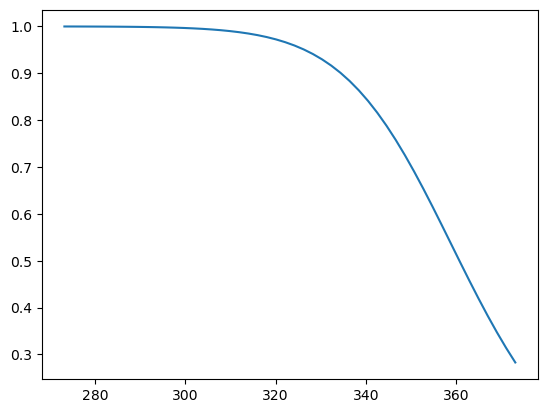

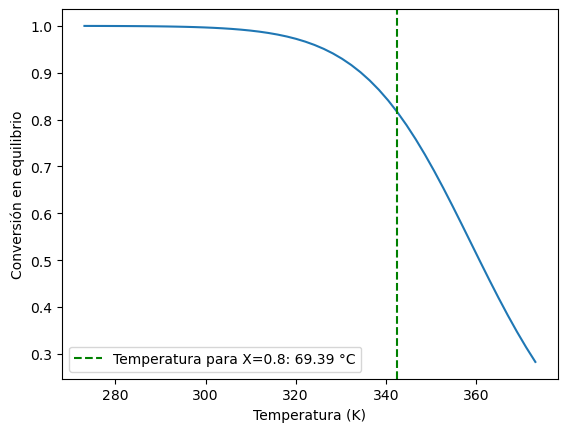

In [178]:
def K_T(T):
    return np.exp(10101.01/T - 28.)

def X_eq(T):
    k = K_T(T)
    return k/(1+k)
T = np.linspace(0, 100) + 273.15
plt.plot(T, X_eq(T))
fig, ax = plt.subplots()
ax.plot(T, X_eq(T))
ax.set_xlabel('Temperatura (K)')
ax.set_ylabel('Conversión en equilibrio')
val_08 = np.where(X_eq(T) >= 0.8)[0][-1]
ax.axvline(T[val_08], color='green', linestyle='--', label=f'Temperatura para X=0.8: {T[val_08]-273.15:.2f} °C')
ax.legend()
fig.savefig('conversion_equilibrio.pdf', bbox_inches='tight', transparent=True)
plt.show()

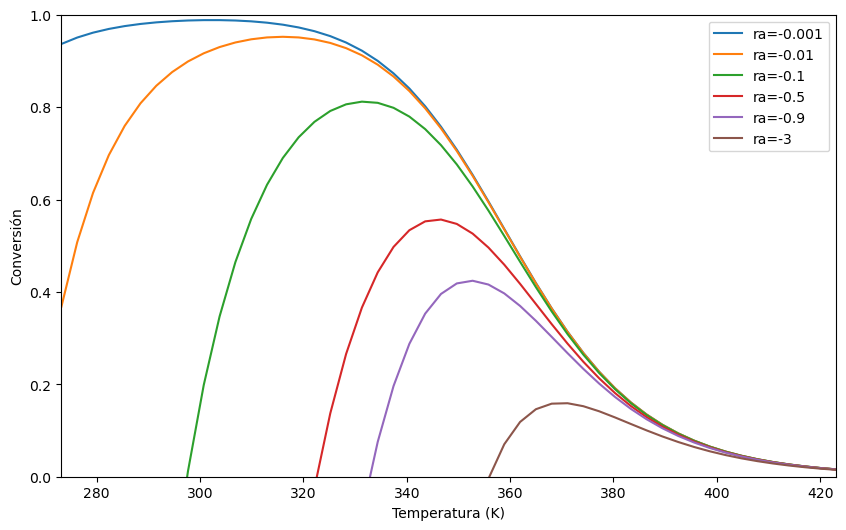

In [179]:
# isolineas
def k1(T):
    k1 = np.exp(18.4 - 12193.8/(1.98*T))
    return k1
def X_A(T, ra, Ca0):
    xa = ((ra * X_eq(T)) / (k1(T)*Ca0)) + X_eq(T)
    return xa

T = np.linspace(0, 150) + 273.15
ra_values = [-0.001, -0.01, -0.1, -0.5, -0.9, -3]
Ca0 = 1
fig, ax = plt.subplots(figsize=(10, 6))
for ra in ra_values:
    ax.plot(T, X_A(T, ra, Ca0), label=f'ra={ra}')
ax.set_xlabel('Temperatura (K)')
ax.set_ylim(0, 1)
ax.set_xlim(273.15, 423.15)
ax.set_ylabel('Conversión')
ax.legend()
fig.savefig('conversion_isotermico.pdf', bbox_inches='tight', transparent=True)
plt.show()

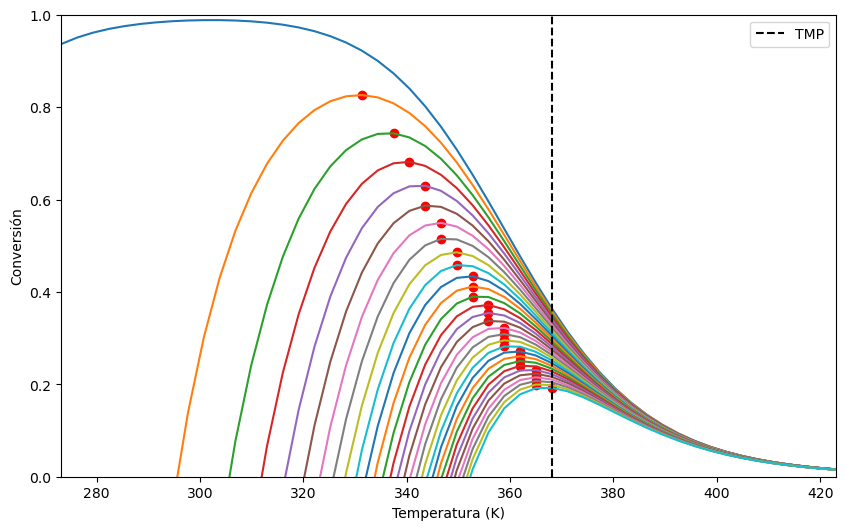

In [180]:
# isolineas
def k1(T):
    k1 = np.exp(18.4 - 12193.8 / (1.98 * T))
    return k1


def X_A(T, ra, Ca0):
    xa = ((ra * X_eq(T)) / (k1(T) * Ca0)) + X_eq(T)
    return xa


T = np.linspace(0, 150) + 273.15
ra_values = np.linspace(-0.001, -2.5, 30)
Ca0 = 1
fig, ax = plt.subplots(figsize=(10, 6))
maxi = []
for ra in ra_values:
    ax.plot(T, X_A(T, ra, Ca0))
    max_xa = np.max(X_A(T, ra, Ca0))
    if max_xa < 0.9:
        ax.scatter(T[np.argmax(X_A(T, ra, Ca0))], max_xa, color='red')
        maxi.append((ra, max_xa))
ax.set_xlabel("Temperatura (K)")
ax.set_ylim(0, 1)
ax.set_xlim(273.15, 423.15)
ax.axvline(95 + 273.15, color="black", linestyle="--", label = 'TMP')
ax.set_ylabel("Conversión")
ax.legend()
fig.savefig("conversion_isotermico_poc.pdf", bbox_inches="tight", transparent=True)
plt.show()

<Figure size 1000x600 with 0 Axes>

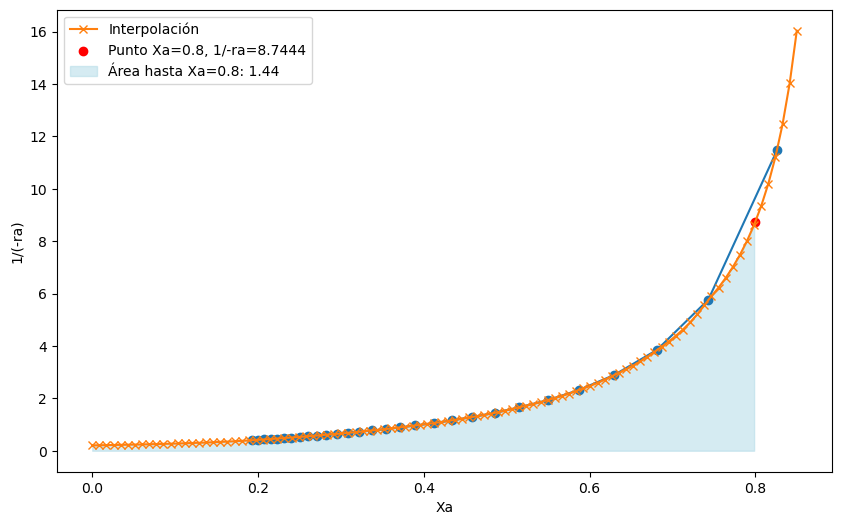

In [181]:
maxi = np.array(maxi)
plt.figure(figsize=(10, 6))
xa, ra = maxi[:, 1], maxi[:, 0]
fig, ax = plt.subplots(figsize=(10, 6))

interpolacion = scipy.interpolate.interp1d(xa, ra, kind='linear', fill_value="extrapolate")


ax.plot(xa, 1/-ra, marker='o')

xa_dato = np.linspace(0., 0.85, 100)
ra_dato = interpolacion(xa_dato)
ax.plot(xa_dato, 1/-ra_dato, marker='x', label='Interpolación')
ax.scatter(0.8, 1/-interpolacion(0.8), color='red', label=f'Punto Xa=0.8, 1/-ra={1/(-interpolacion(0.8)):.4f}')
### Area hasta 0.8
area = scipy.integrate.trapezoid(1/-ra_dato[xa_dato <= 0.80], xa_dato[xa_dato <= 0.80])
ax.fill_between(xa_dato, 1/-ra_dato, where=(xa_dato <= 0.80), color='lightblue', alpha=0.5,
                 label=f'Área hasta Xa=0.8: {area:.2f}')

ax.set_xlabel('Xa')
ax.set_ylabel('1/(-ra)')
ax.legend()
fig.savefig('interpolacion_ra.pdf', bbox_inches='tight', transparent=True)

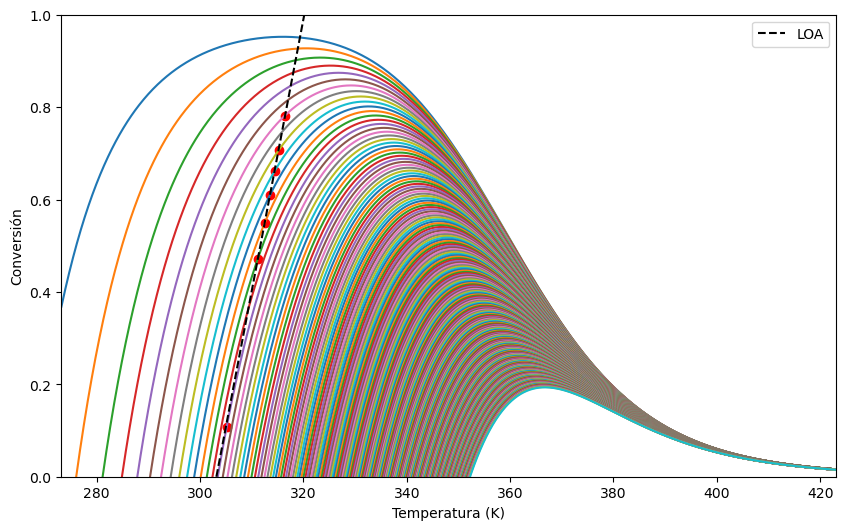

In [182]:
# LOA

def LOA(T): 
    T = T - 273.15
    return 0.0588 * T - 1.764 

T = np.linspace(0, 150, 1000) + 273.15
ra_values = np.arange(-0.01, -2.5, -0.01) 
Ca0 = 1
fig, ax = plt.subplots(figsize=(10, 6))
ra_vals_save, xa_vals_save = [], []
for ra in ra_values:
    ax.plot(T, X_A(T, ra, Ca0))
    # intersección con LOA
    xa_vals = X_A(T, ra, Ca0)
    loa_vals = LOA(T)
    diff = np.abs(xa_vals - loa_vals)
    idx_intersection = np.argmin(diff)
    if diff[idx_intersection] < 0.05 and 0 <= xa_vals[idx_intersection] <= 0.8:  # umbral para considerar la intersección
        ax.scatter(T[idx_intersection], xa_vals[idx_intersection], color='red')
        ra_vals_save.append(ra)
        xa_vals_save.append(xa_vals[idx_intersection])
        
ax.plot(T, LOA(T), label="LOA", color="black", linestyle="--")
ax.set_xlabel("Temperatura (K)")
ax.set_ylim(0, 1)
ax.set_xlim(273.15, 423.15)
ax.set_ylabel("Conversión")
ax.legend()
fig.savefig("conversion_isotermico_LOA.pdf", bbox_inches="tight", transparent=True)
plt.show()

<Figure size 1000x600 with 0 Axes>

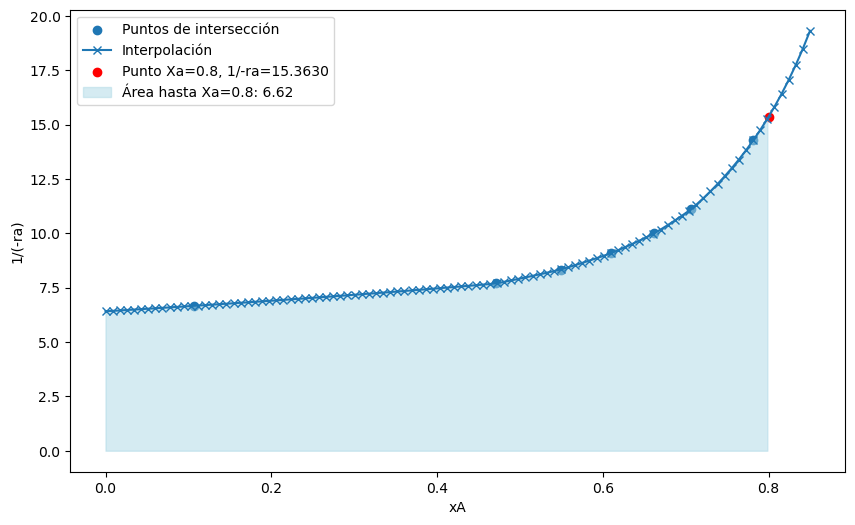

In [183]:
ra, xa = ra_vals_save, xa_vals_save
ra = np.array(ra)
xa = np.array(xa)
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(xa, 1/-ra, marker='o', label='Puntos de intersección')
ax.set_xlabel('xA')
ax.set_ylabel('1/(-ra)')

### interpolación
interpolacion = scipy.interpolate.interp1d(xa, ra, kind='linear', fill_value="extrapolate")
xa_dato = np.linspace(0., 0.85, 100)
ra_dato = interpolacion(xa_dato)
ax.plot(xa_dato, 1/-ra_dato, marker='x', label='Interpolación')
ax.scatter(0.8, 1/-interpolacion(0.8), color='red', label=f'Punto Xa=0.8, 1/-ra={1/(-interpolacion(0.8)):.4f}')
### Area hasta 0.8
area = scipy.integrate.trapezoid(1/-ra_dato[xa_dato <= 0.80], xa_dato[xa_dato <= 0.80])
ax.fill_between(xa_dato, 1/-ra_dato, where=(xa_dato <= 0.80), color='lightblue', alpha=0.5, label=f'Área hasta Xa=0.8: {area:.2f}') 


ax.legend()

fig.savefig('interpolacion_ra_LOA.pdf', bbox_inches='tight', transparent=True)

# 4.

In [184]:
##constantes del problema
F_Ao = 5  # mol/s
C_Ao = 1  # mol/L
delta_Hrx = -33472  # J/mol
U_a = 5000
T_a = 700  # K (coolant)
Cp = 122  # J/(mol*K)

In [185]:
def k1(T):
    return 10**3 * np.exp(-4800 / (8.31 * T))


def sistema_EDOs(V, y):
    X_A, T = y
    ra = k1(T) * C_Ao * (1 - X_A)  ##en verdad aqui se calcula -rA
    dXA_dV = ra / F_Ao
    dT_dV = (ra * (delta_Hrx) - U_a * (T - T_a)) / (F_Ao * Cp)
    return [dXA_dV, dT_dV]

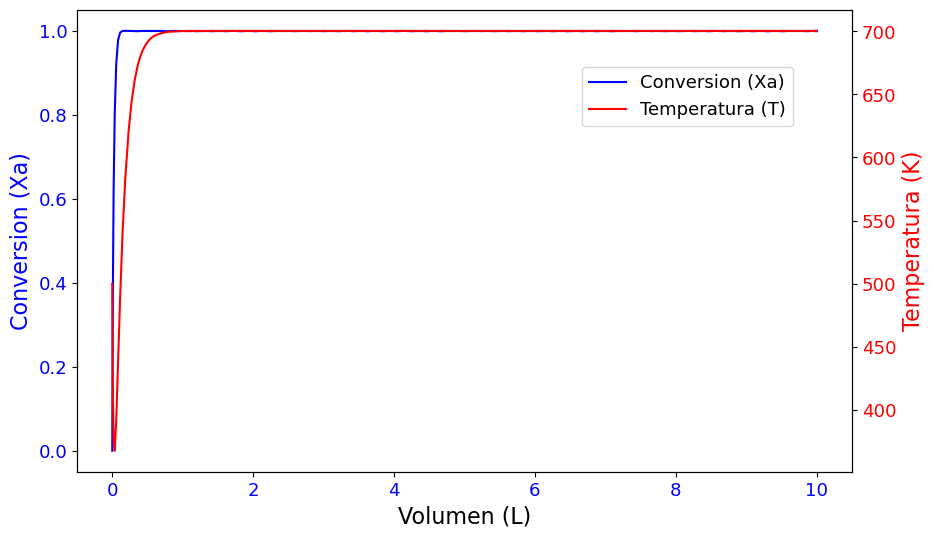

In [186]:
yo = [0, 500]
V_eval = [0, 10]
sol = scipy.integrate.solve_ivp(sistema_EDOs, V_eval, y0=yo, method="RK45", max_step=0.1)

Xa_v = sol.y[0]
T_v = sol.y[1]

label_fs = 16
tick_fs = 13
legend_fs = 13

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(sol.t, Xa_v, label="Conversion (Xa)", color="blue")
ax1.set_xlabel("Volumen (L)", fontsize=label_fs)
ax1.set_ylabel("Conversion (Xa)", color="blue", fontsize=label_fs)
ax1.tick_params(axis="both", labelsize=tick_fs, labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(sol.t, T_v, label="Temperatura (T)", color="red")
ax2.set_ylabel("Temperatura (K)", color="red", fontsize=label_fs)
ax2.tick_params(axis="y", labelsize=tick_fs, labelcolor="red")

fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.8), fontsize=legend_fs)
fig.savefig("perfil_V.pdf", bbox_inches="tight", transparent=True)
plt.show()